<a href="https://colab.research.google.com/github/porquenogr/precision-livestock-ai/blob/main/06_annotation_conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "trainingdatapro/farm-animals-pigs-detection-dataset"
)

print("[INFO] Dataset downloaded to:", dataset_path)

100%|██████████| 5.15M/5.15M [00:00<00:00, 200MB/s]

Extracting files...
[INFO] Dataset downloaded to: /root/.cache/kagglehub/datasets/trainingdatapro/farm-animals-pigs-detection-dataset/versions/1


In [ ]:
from pathlib import Path

source_path = Path(dataset_path)
xml_file = source_path / "annotations.xml"

print("[INFO] XML exists:", xml_file.exists())
print("[INFO] XML path:", xml_file)

[INFO] XML exists: True
[INFO] XML path: /root/.cache/kagglehub/datasets/trainingdatapro/farm-animals-pigs-detection-dataset/versions/1/annotations.xml


In [ ]:
from xml.etree import ElementTree as ET

tree = ET.parse(xml_file)
root = tree.getroot()

first_image = root.findall("image")[0]

print("[INFO] Image:", first_image.get("name"))
print("[INFO] Size:", first_image.get("width"), "x", first_image.get("height"))

box = first_image.find("box")

print("[INFO] Label:", box.get("label"))
print("[INFO] CVAT coordinates:")
print(
    "xtl =", box.get("xtl"),
    "ytl =", box.get("ytl"),
    "xbr =", box.get("xbr"),
    "ybr =", box.get("ybr")
)

[INFO] Image: images/01.png
[INFO] Size: 199 x 174
[INFO] Label: pig_face
[INFO] CVAT coordinates:
xtl = 59.50 ytl = 18.27 xbr = 142.30 ybr = 109.00


In [ ]:
image_width = int(first_image.get("width"))
image_height = int(first_image.get("height"))

xtl = float(box.get("xtl"))
ytl = float(box.get("ytl"))
xbr = float(box.get("xbr"))
ybr = float(box.get("ybr"))

x_center = ((xtl + xbr) / 2) / image_width
y_center = ((ytl + ybr) / 2) / image_height
width = (xbr - xtl) / image_width
height = (ybr - ytl) / image_height

print("[INFO] YOLO coordinates:")
print("x_center:", x_center)
print("y_center:", y_center)
print("width:", width)
print("height:", height)

[INFO] YOLO coordinates:
x_center: 0.5070351758793971
y_center: 0.36571839080459767
width: 0.4160804020100503
height: 0.5214367816091954


In [ ]:
from pathlib import Path

labels_dir = Path("yolo_labels")
labels_dir.mkdir(exist_ok=True)

class_mapping = {
    "pig_face": 0
}

for image in root.findall("image"):

    image_name = Path(image.get("name")).stem
    image_width = int(image.get("width"))
    image_height = int(image.get("height"))

    yolo_lines = []

    for box in image.findall("box"):

        label = box.get("label")
        class_id = class_mapping[label]

        xtl = float(box.get("xtl"))
        ytl = float(box.get("ytl"))
        xbr = float(box.get("xbr"))
        ybr = float(box.get("ybr"))

        x_center = ((xtl + xbr) / 2) / image_width
        y_center = ((ytl + ybr) / 2) / image_height
        width = (xbr - xtl) / image_width
        height = (ybr - ytl) / image_height

        yolo_line = (
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

        yolo_lines.append(yolo_line)

    label_file = labels_dir / f"{image_name}.txt"
    label_file.write_text("\n".join(yolo_lines))

print(f"[SUCCESS] Converted {len(list(root.findall('image')))} images.")
print(f"[INFO] YOLO labels saved to: {labels_dir}")

[SUCCESS] Converted 27 images.
[INFO] YOLO labels saved to: yolo_labels


In [ ]:
label_file = labels_dir / "01.txt"

print("[INFO] Contents of 01.txt:")
print(label_file.read_text())

[INFO] Contents of 01.txt:
0 0.507035 0.365718 0.416080 0.521437


In [ ]:
label_files = list(labels_dir.glob("*.txt"))

print("[INFO] Number of YOLO label files:", len(label_files))
print("[INFO] First 5 files:")

for file in label_files[:5]:
    print(" -", file.name)

[INFO] Number of YOLO label files: 27
[INFO] First 5 files:
 - 09.txt
 - 06.txt
 - 03.txt
 - 08.txt
 - 11.txt


In [ ]:
from pathlib import Path

dataset_dir = Path("pig_yolo_dataset")

train_images = dataset_dir / "images" / "train"
val_images = dataset_dir / "images" / "val"

train_labels = dataset_dir / "labels" / "train"
val_labels = dataset_dir / "labels" / "val"

for folder in [train_images, val_images, train_labels, val_labels]:
    folder.mkdir(parents=True, exist_ok=True)

print("[INFO] YOLO dataset folders created.")

[INFO] YOLO dataset folders created.


In [ ]:
import random
import shutil

source_images = source_path / "images"

image_files = sorted(source_images.glob("*.png"))

random.seed(42)
random.shuffle(image_files)

split_index = int(len(image_files) * 0.8)

train_files = image_files[:split_index]
val_files = image_files[split_index:]

print("[INFO] Total images:", len(image_files))
print("[INFO] Training images:", len(train_files))
print("[INFO] Validation images:", len(val_files))

[INFO] Total images: 27
[INFO] Training images: 21
[INFO] Validation images: 6


In [ ]:
for image_file in train_files:
    label_file = labels_dir / f"{image_file.stem}.txt"

    shutil.copy2(image_file, train_images / image_file.name)
    shutil.copy2(label_file, train_labels / label_file.name)


for image_file in val_files:
    label_file = labels_dir / f"{image_file.stem}.txt"

    shutil.copy2(image_file, val_images / image_file.name)
    shutil.copy2(label_file, val_labels / label_file.name)


print("[SUCCESS] Images and labels copied.")
print("[INFO] Train images:", len(list(train_images.glob("*.png"))))
print("[INFO] Train labels:", len(list(train_labels.glob("*.txt"))))
print("[INFO] Val images:", len(list(val_images.glob("*.png"))))
print("[INFO] Val labels:", len(list(val_labels.glob("*.txt"))))

[SUCCESS] Images and labels copied.
[INFO] Train images: 21
[INFO] Train labels: 21
[INFO] Val images: 6
[INFO] Val labels: 6


In [ ]:
yaml_path = dataset_dir / "data.yaml"

yaml_content = f"""path: {dataset_dir.resolve()}
train: images/train
val: images/val

names:
  0: pig_face
"""

yaml_path.write_text(yaml_content)

print("[SUCCESS] data.yaml created:")
print(yaml_path.read_text())

[SUCCESS] data.yaml created:
path: /content/pig_yolo_dataset
train: images/train
val: images/val

names:
  0: pig_face



In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 631.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.3 MB/s eta 0:00:00


In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "trainingdatapro/farm-animals-pigs-detection-dataset"
)

print(dataset_path)

100%|██████████| 5.15M/5.15M [00:01<00:00, 4.38MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/trainingdatapro/farm-animals-pigs-detection-dataset/versions/1


In [8]:
from pathlib import Path

source_path = Path(dataset_path)

print("XML:", (source_path / "annotations.xml").exists())
print("Images:", (source_path / "images").exists())

XML: True
Images: True


In [9]:
from pathlib import Path
from xml.etree import ElementTree as ET
import shutil
import random

source_path = Path(dataset_path)
xml_file = source_path / "annotations.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

dataset_dir = Path("/content/pig_yolo_dataset")

train_images = dataset_dir / "images" / "train"
val_images = dataset_dir / "images" / "val"
train_labels = dataset_dir / "labels" / "train"
val_labels = dataset_dir / "labels" / "val"

for folder in [train_images, val_images, train_labels, val_labels]:
    folder.mkdir(parents=True, exist_ok=True)

labels_dir = Path("/content/yolo_labels")
labels_dir.mkdir(exist_ok=True)

for image in root.findall("image"):
    image_name = Path(image.get("name")).stem
    image_width = int(image.get("width"))
    image_height = int(image.get("height"))

    lines = []

    for box in image.findall("box"):
        xtl = float(box.get("xtl"))
        ytl = float(box.get("ytl"))
        xbr = float(box.get("xbr"))
        ybr = float(box.get("ybr"))

        x_center = ((xtl + xbr) / 2) / image_width
        y_center = ((ytl + ybr) / 2) / image_height
        width = (xbr - xtl) / image_width
        height = (ybr - ytl) / image_height

        lines.append(
            f"0 {x_center:.6f} {y_center:.6f} "
            f"{width:.6f} {height:.6f}"
        )

    (labels_dir / f"{image_name}.txt").write_text("\n".join(lines))

image_files = sorted((source_path / "images").glob("*.png"))

random.seed(42)
random.shuffle(image_files)

split_index = int(len(image_files) * 0.8)

train_files = image_files[:split_index]
val_files = image_files[split_index:]

for image_file in train_files:
    shutil.copy2(image_file, train_images / image_file.name)
    shutil.copy2(
        labels_dir / f"{image_file.stem}.txt",
        train_labels / f"{image_file.stem}.txt"
    )

for image_file in val_files:
    shutil.copy2(image_file, val_images / image_file.name)
    shutil.copy2(
        labels_dir / f"{image_file.stem}.txt",
        val_labels / f"{image_file.stem}.txt"
    )

yaml_path = dataset_dir / "data.yaml"

yaml_path.write_text(f"""path: {dataset_dir}
train: images/train
val: images/val

names:
  0: pig_face
""")

print("[SUCCESS] Dataset restored.")
print("Train:", len(train_files))
print("Validation:", len(val_files))
print("data.yaml:", yaml_path.exists())

[SUCCESS] Dataset restored.
Train: 21
Validation: 6
data.yaml: True


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=4,
    project="pig_face_training",
    name="yolov8n_pig_face"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pig_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_pig_face, nbs=64, nms=None, opset=None, opti

In [11]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/detect/pig_face_training/yolov8n_pig_face/weights/best.pt"
)

results = best_model.predict(
    source="/content/pig_yolo_dataset/images/val",
    conf=0.25,
    save=True
)


image 1/6 /content/pig_yolo_dataset/images/val/01.png: 576x640 2 pig_faces, 240.6ms
image 2/6 /content/pig_yolo_dataset/images/val/04.png: 640x576 (no detections), 418.5ms
image 3/6 /content/pig_yolo_dataset/images/val/08.png: 640x640 (no detections), 130.0ms
image 4/6 /content/pig_yolo_dataset/images/val/09.png: 640x544 (no detections), 114.0ms
image 5/6 /content/pig_yolo_dataset/images/val/21.png: 448x640 (no detections), 103.9ms
image 6/6 /content/pig_yolo_dataset/images/val/25.png: 416x640 1 pig_face, 91.0ms
Speed: 5.8ms preprocess, 183.0ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


In [12]:
from pathlib import Path

pred_dir = Path("/content/runs/detect/predict")

print([p.name for p in pred_dir.glob("*.png")])

[]


In [13]:
from pathlib import Path

pred_dir = Path("/content/runs/detect/predict")

print([p.name for p in pred_dir.iterdir()])

['09.jpg', '01.jpg', '21.jpg', '04.jpg', '25.jpg', '08.jpg']


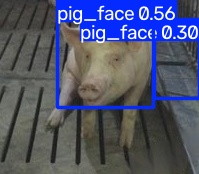

In [14]:
from IPython.display import display
from PIL import Image

img = Image.open("/content/runs/detect/predict/01.jpg")
display(img)

01.jpg


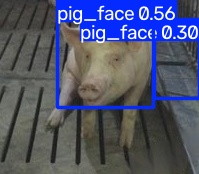

04.jpg


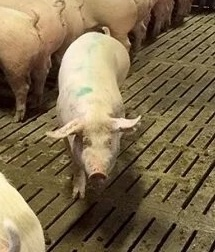

08.jpg


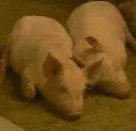

09.jpg


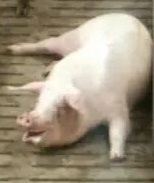

21.jpg


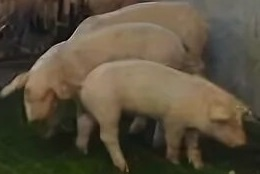

25.jpg


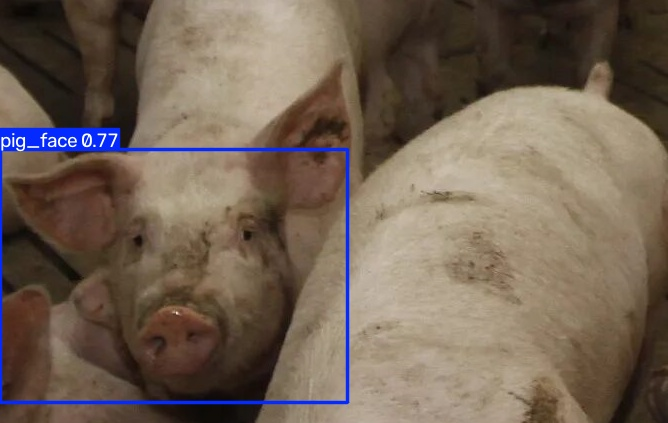

In [15]:
from IPython.display import display
from PIL import Image
from pathlib import Path

pred_dir = Path("/content/runs/detect/predict")

for img_path in sorted(pred_dir.glob("*.jpg")):
    print(img_path.name)
    display(Image.open(img_path))